# Shania Phillips and Maria Aponte Rosero

## Analyzing the impact of COVID-19 on New Orleans Education

### https://sphil5.github.io/

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np

Mounted at /content/drive


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Data_Dashboard_export_2026-03-06-17-55-40.xlsx to Data_Dashboard_export_2026-03-06-17-55-40.xlsx
Saving Data_Dashboard_export_2026-03-06-17-46-04.xlsx to Data_Dashboard_export_2026-03-06-17-46-04.xlsx


###Project Goals
Our goal for this project is to investigate the impact of COVID-19 on public school education in New Orleans, Louisiana. We will analyze the changes in performance scores, attendance, and more from the 2020-2021 school year, the school year following COVID-19, to the most recent completed school year 2024-2025.

### Collaboration Plan

Our plan for collaborating is to meet once a week to work on this project. We have a Github repository set up to share and update our code. We plan to additionally communicate through text to assist each other when needed.

###Dataset 1

The first dataset we are considering using is the Key Academic Metrics from [NOLA Public Schools](https://data.nolapublicschools.com/data-library/). This dataset contains school performace score, assessment index, and progress index of New Orleans public schools. This dataset might be useful in analyzing how schools have been performing the past few years following COVID-19 and their growth.

Since this dataset supplies us with data from the school years since Covid-19 to the most recent completed school year, we can use this data to compare the educational trends of each year to dive deeper into how schools have been impacted yearly since the pandemic. With this analyzation we will be able to answer questions like was the pandemic detrimental to the trajectory of New Orleans education and how has it been impacted in the recent years.

In [ ]:
df1 = pd.read_excel("Data_Dashboard_export_2026-03-06-17-46-04.xlsx")

df1.head()

,School Name,School Year,Site Code,School Type,Grade Configuration,Subgroup,Domain,% Attaining Top Growth,NOLA-PS SPRI,NOLA-PS SPRI Letter Grade,School Performance Score (SPS),SPS Letter Grade,Assessment Index,NOLA-PS Assessment Index,Assessment Index Letter Grade,Progress Index,Progress Index Letter Grade,NOLA-PS Progress Index,NOLA-PS Top Growth %,Graduation Rate
0,International School of Louisiana,2020-2021,331001,Type 2,K-8,All Students,Quality,48.0,NaN,NaN,73.6,NaN,59.0,NaN,NaN,90.2,NaN,83.3,44.0,NaN
1,International School of Louisiana,2021-2022,331001,Type 2,K-8,All Students,Quality,48.0,NaN,NaN,80.0,B,66.7,60.3,C,89.2,B,86.0,46.0,NaN
2,International School of Louisiana,2022-2023,331001,Type 2,K-8,All Students,Quality,52.0,NaN,NaN,78.3,B,67.8,42.7,C,95.6,A,94.0,51.0,NaN
3,International School of Louisiana,2023-2024,331001,Type 2,K-8,All Students,Quality,51.0,NaN,NaN,84.2,B,72.8,51.2,C,96.8,A,95.6,52.0,NaN
4,International School of Louisiana,2024-2025,331001,Type 2,K-8,All Students,Quality,50.0,NaN,NaN,84.4,B,73.5,NaN,C,96.4,A,NaN,NaN,NaN


### Data Cleaning (ETL)
We cleaned up this dataset by performing a few different tasks.

First, we changed the column names to make them easier to reference in code.

Next, we removed any missing data from the school performance scores column to focus on the information present for our statistics and visualization.

Lastly, we got rid of columns that had most of its data missing since it would not be as useful to our investigation.

In [ ]:
# Change the column names to lowercase and replace the spaces with underscores to make them easier to work with
df1.columns = df1.columns.str.lower().str.replace(" ", "_")

# Drop rows with missing performance scores
df1 = df1.dropna(subset=["school_performance_score_(sps)"])

# Check missing values
df1.isna().sum()

# Drop columns that are missing a lot of data
df1 = df1.drop(columns=[
    "nola-ps_spri",
    "nola-ps_spri_letter_grade"
])

In [ ]:
df1.head(10)

,school_name,school_year,site_code,school_type,grade_configuration,subgroup,domain,%_attaining_top_growth,nola-ps_spri,nola-ps_spri_letter_grade,school_performance_score_(sps),sps_letter_grade,assessment_index,nola-ps_assessment_index,assessment_index_letter_grade,progress_index,progress_index_letter_grade,nola-ps_progress_index,nola-ps_top_growth_%,graduation_rate
0,International School of Louisiana,2020-2021,331001,Type 2,K-8,All Students,Quality,48.0,NaN,NaN,73.6,NaN,59.0,NaN,NaN,90.2,NaN,83.3,44.0,NaN
1,International School of Louisiana,2021-2022,331001,Type 2,K-8,All Students,Quality,48.0,NaN,NaN,80.0,B,66.7,60.3,C,89.2,B,86.0,46.0,NaN
2,International School of Louisiana,2022-2023,331001,Type 2,K-8,All Students,Quality,52.0,NaN,NaN,78.3,B,67.8,42.7,C,95.6,A,94.0,51.0,NaN
3,International School of Louisiana,2023-2024,331001,Type 2,K-8,All Students,Quality,51.0,NaN,NaN,84.2,B,72.8,51.2,C,96.8,A,95.6,52.0,NaN
4,International School of Louisiana,2024-2025,331001,Type 2,K-8,All Students,Quality,50.0,NaN,NaN,84.4,B,73.5,NaN,C,96.4,A,NaN,NaN,NaN
5,New Orleans Center for Creative Arts,2020-2021,334001,Type 2,HS,All Students,Quality,50.0,NaN,NaN,109.7,NaN,91.1,NaN,NaN,100.5,NaN,80.3,44.0,>95%
6,New Orleans Center for Creative Arts,2021-2022,334001,Type 2,HS,All Students,Quality,49.0,NaN,NaN,104.6,A,84.8,40.4,B,96.5,A,81.0,46.0,91.7
7,New Orleans Center for Creative Arts,2022-2023,334001,Type 2,HS,All Students,Quality,43.0,NaN,NaN,96.5,A,88.2,39.2,B,92.4,A,86.1,51.0,88.7
8,New Orleans Center for Creative Arts,2023-2024,334001,Type 2,HS,All Students,Quality,44.0,NaN,NaN,91.3,A,87.9,51.2,B,91.2,A,87.7,52.0,>95%
9,New Orleans Center for Creative Arts,2024-2025,334001,Type 2,HS,All Students,Quality,46.0,NaN,NaN,103.5,A,86.3,NaN,B,92.0,A,NaN,NaN,>95%


### Interesting Statistics

Key statistics include:
- There are 75 schools included in this dataset.
- The average performance score has increased since the 2020-2021 school year. It has risen from 64.53 to 74.67.
- Benjamin Franklin High School has the highest perfomace score of 133.9 which occured in the 2024-2025 school year.
- Thurgood Marshall had the lowest performance score of 40.9 which occured in the 2020-2021 school year.

These statistics are important because they inform us of when the highest and and lowest performance scores occured as well as the overall average amongst the years. This gives us an indication on the trend of performance score growth since the pandemic.

In [ ]:
# Calculate the number of unique schools in dataset since each school is repeated multiple times for different years
num_schools = df1["school_name"].nunique()

# Calculate the average performance score of each year
avg_performance_per_year = df1.groupby("school_year")["school_performance_score_(sps)"].mean()

# Find the school with the highest performance score
max_score = df1.loc[df1["school_performance_score_(sps)"].idxmax()]

# Find the school with the lowest performance score
min_score = df1.loc[df1["school_performance_score_(sps)"].idxmin()]

# Print results
print("Number of schools:", num_schools)
print("Average performance score per year", avg_performance_per_year)
print("Highest score:", max_score)
print("Lowest score:", min_score)

Number of schools: 75
Average performance score per year school_year
2020-2021    64.532308
2021-2022    66.477143
2022-2023    70.573239
2023-2024    74.153425
2024-2025    74.668493
Name: school_performance_score_(sps), dtype: float64
Highest score: school_name                       Benjamin Franklin High School
school_year                                           2024-2025
site_code                                                WBB001
school_type                                           Selective
grade_configuration                                          HS
subgroup                                           All Students
domain                                                  Quality
%_attaining_top_growth                                     72.0
nola-ps_spri                                                NaN
nola-ps_spri_letter_grade                                   NaN
school_performance_score_(sps)                            133.9
sps_letter_grade                            

### Visualization
This visulaization shows the average performace score in the dataset for each school year since the 2020-2021 school year.

This graph allows us to evaluate how the performance scores have changed since Covid-19. Analyzing this data allows us to see whether the school performance score has increased, decreased, or stayed the same since the pandemic.

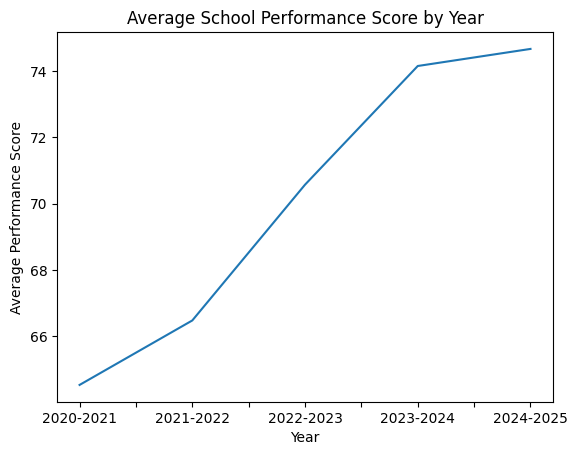

In [ ]:
import matplotlib.pyplot as plt

# Plot the change in the average performance score throughout the  school years.
avg_performance_per_year.plot()

# Label the graph
plt.title("Average School Performance Score by Year")
plt.xlabel("Year")
plt.ylabel("Average Performance Score")
plt.show()

###Dataset 2
The second dataset we are considering using is the High School Performance from [NOLA Public Schools](https://data.nolapublicschools.com/data-library/).

This dataset contains information about school performance metrics such as performance scores, graduation rates, and other academic indicators for high schools in New Orleans.

Key variables include:
- School name
- School year
- Performance score
- Graduation rates or related indicators

These metrics allow us to examine how high school performance has changed over time, particularly before and after the COVID-19 pandemic.

In [ ]:
df2 = pd.read_excel("Data_Dashboard_export_2026-03-06-17-55-40.xlsx")

df2.head()

,School Name,School Year,Site Code,School Type,Grade Configuration,Subgroup,Domain,Open Enrollment Average ACT Composite Score,Average ACT Composite Score
0,International School of Louisiana,2020-2021,331001,Type 2,K-8,All Students,Quality,NaN,NaN
1,International School of Louisiana,2021-2022,331001,Type 2,K-8,All Students,Quality,NaN,NaN
2,International School of Louisiana,2022-2023,331001,Type 2,K-8,All Students,Quality,NaN,NaN
3,International School of Louisiana,2023-2024,331001,Type 2,K-8,All Students,Quality,NaN,NaN
4,International School of Louisiana,2024-2025,331001,Type 2,K-8,All Students,Quality,NaN,NaN


### Data Cleaning (ETL)

To prepare the dataset for analysis, several cleaning steps were performed.

First, column names were standardized by converting them to lowercase and replacing spaces with underscores. This makes the dataset easier to work with in Python.

Next, we inspected the dataset structure and checked for missing values. Rows containing missing data were removed to ensure the analysis uses complete observations.

Finally, duplicate rows were removed to prevent repeated observations from biasing the results. These steps ensure the dataset is tidy and ready for exploratory analysis.

In [ ]:
# Change the column names to lowercase and replace the spaces with underscores to make them easier to work with
df2.columns = df2.columns.str.lower().str.replace(" ", "_")

df2.info()
df2.isna().sum()
df2 = df2.dropna()
df2 = df2.drop_duplicates()
df2.describe()

df2.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 9 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   school_name                                  367 non-null    object 
 1   school_year                                  367 non-null    object 
 2   site_code                                    367 non-null    object 
 3   school_type                                  367 non-null    object 
 4   grade_configuration                          367 non-null    object 
 5   subgroup                                     367 non-null    object 
 6   domain                                       367 non-null    object 
 7   open_enrollment_average_act_composite_score  107 non-null    float64
 8   average_act_composite_score                  136 non-null    float64
dtypes: float64(2), object(7)
memory usage: 25.9+ KB


,school_name,school_year,site_code,school_type,grade_configuration,subgroup,domain,open_enrollment_average_act_composite_score,average_act_composite_score
5,New Orleans Center for Creative Arts,2020-2021,334001,Type 2,HS,All Students,Quality,16.0,22.1
6,New Orleans Center for Creative Arts,2021-2022,334001,Type 2,HS,All Students,Quality,15.9,21.4
7,New Orleans Center for Creative Arts,2022-2023,334001,Type 2,HS,All Students,Quality,15.9,22.4
8,New Orleans Center for Creative Arts,2023-2024,334001,Type 2,HS,All Students,Quality,15.9,21.6
10,International High School of New Orleans,2020-2021,344001,Type 2,HS,All Students,Quality,16.0,15.8


### Interesting Statistics

The dataset includes ACT performance information for multiple high schools in New Orleans across several academic years.

Some key summary statistics include:

- The dataset contains 27 unique schools across 4 school years.
- The average ACT composite score across all schools is 17.1010101010101.
- The highest ACT score observed in the dataset is 28.2, while the lowest score is 12.9.

These statistics help summarize the overall academic performance of high schools in the dataset. They are relevant because ACT scores provide a measurable way to compare school performance across years and identify broader trends in educational outcomes.

In [ ]:
# Number of unique schools in the dataset
num_schools = df2['school_name'].nunique()
print("Number of unique schools:", num_schools)

# Number of school years included
num_years = df2['school_year'].nunique()
print("Number of school years:", num_years)

# Average ACT composite score across all schools
avg_act = df2['average_act_composite_score'].mean()
print("Average ACT Composite Score:", avg_act)

# Highest ACT composite score
max_act = df2['average_act_composite_score'].max()
print("Highest ACT Composite Score:", max_act)

# Lowest ACT composite score
min_act = df2['average_act_composite_score'].min()
print("Lowest ACT Composite Score:", min_act)

act_by_year = df2.groupby('school_year')['average_act_composite_score'].mean()
print(act_by_year)

Number of unique schools: 27
Number of school years: 4
Average ACT Composite Score: 17.1010101010101
Highest ACT Composite Score: 28.2
Lowest ACT Composite Score: 12.9
school_year
2020-2021    17.136364
2021-2022    16.979167
2022-2023    17.146154
2023-2024    17.137037
Name: average_act_composite_score, dtype: float64


### Visualization

The graph below shows the average ACT composite score across different school years.

This visualization helps illustrate how high school academic performance has changed over time.
By examining the trend in ACT scores, we can observe whether student performance improved, declined, or remained stable across different years.

Visualizing this trend helps identify patterns that may relate to disruptions in education during the COVID-19 pandemic.

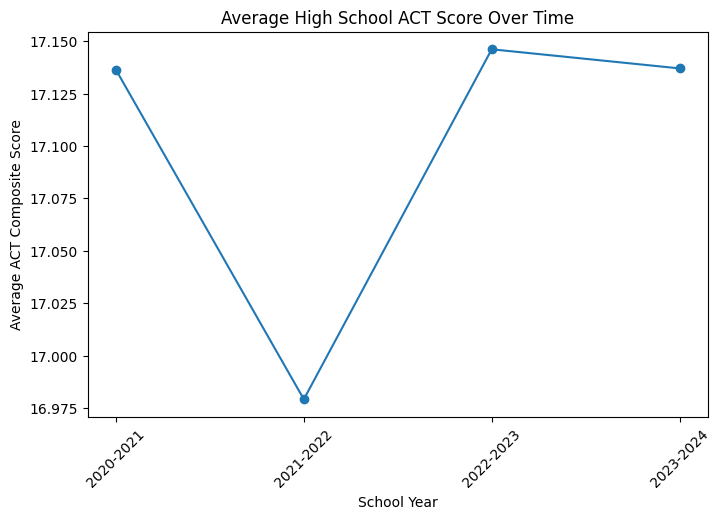

In [ ]:
import matplotlib.pyplot as plt

# Calculate the average ACT composite score across different school years
avg_scores = df2.groupby('school_year')['average_act_composite_score'].mean()

# Plot and label the graph
plt.figure(figsize=(8,5))
plt.plot(avg_scores.index, avg_scores.values, marker='o')
plt.title("Average High School ACT Score Over Time")
plt.xlabel("School Year")
plt.ylabel("Average ACT Composite Score")
plt.xticks(rotation=45)
plt.show()

In [ ]:
%%shell
jupyter nbconvert --to html /content/Phillips_Rosero_Milestone_1.ipynb

[NbConvertApp] Converting notebook /content/Phillips_Rosero_Milestone_1.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 435189 bytes to /content/Phillips_Rosero_Milestone_1.html


In [ ]:
from google.colab import drive
drive.mount('/content/drive')